In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPool2D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import cifar10

In [2]:
np.random.seed(42)
tf.random.set_seed(42)

In [3]:
tf.random.uniform([1])

<tf.Tensor: shape=(1,), dtype=float32, numpy=array([0.6645621], dtype=float32)>

In [4]:
(X_train,y_train),(X_test,y_test) = cifar10.load_data()

In [5]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [6]:
X_train = X_train / 255
X_test = X_test / 255

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img,img_to_array

How to using data augmantation.

In [8]:
data_gen = ImageDataGenerator(width_shift_range=0.1 , height_shift_range=0.1 , horizontal_flip=True)

In [9]:
batch_size = 50

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train , X_val , y_train , y_val = train_test_split(X_train , y_train , test_size=0.2 ,random_state=42)

In [12]:
train_data_gen = data_gen.flow(x=X_train , y=y_train , batch_size=batch_size)

In [13]:
model = keras.models.Sequential()
model.add(Conv2D(filters=32,kernel_size=(3,3),padding='same',activation='relu', input_shape=(32,32,3)))
model.add(Dropout(0.25))
model.add(Conv2D(filters=32,kernel_size=(3,3),padding='same',activation='relu'))
model.add(Conv2D(filters=32,kernel_size=(3,3),padding='same',activation='relu'))
model.add(Dropout(0.25))
model.add(MaxPool2D())
model.add(Conv2D(filters=64,kernel_size=(3,3),padding='same',activation='relu'))
model.add(Conv2D(filters=64,kernel_size=(3,3),padding='same',activation='relu'))
model.add(Dropout(0.25))
model.add(Conv2D(filters=64,kernel_size=(3,3),padding='same',activation='relu'))
model.add(Dropout(0.25))
model.add(MaxPool2D())
model.add(Conv2D(filters=128,kernel_size=(3,3),padding='same',activation='relu'))
model.add(Dropout(0.25))
model.add(Conv2D(filters=128,kernel_size=(3,3),padding='same',activation='relu'))
model.add(Conv2D(filters=128,kernel_size=(3,3),padding='same',activation='relu'))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(units=512))
model.add(Dropout(0.4))
model.add(Dense(units=256))
model.add(Dropout(0.3))
model.add(Dense(units=10,activation='softmax'))

d:\python-venv\keras2\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,809,482 (18.35 MB)

 Trainable params: 4,809,482 (18.35 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
#lr_schedule = tf.keras.optimizers.schedules.CosineDecay(initial_learning_rate=0.01,decay_steps=9600)

In [16]:
opt = tf.optimizers.Adam(learning_rate=0.0005)
loss = tf.losses.CategoricalCrossentropy()
metr = [tf.metrics.CategoricalAccuracy()]
model.compile(optimizer=opt , loss= loss , metrics= metr)

In [17]:
history = model.fit(train_data_gen , epochs=40 , batch_size=batch_size , validation_data=(X_val,y_val) , verbose=2)

Epoch 1/40
800/800 - 72s - 90ms/step - categorical_accuracy: 0.3176 - loss: 1.8286 - val_categorical_accuracy: 0.3900 - val_loss: 1.6281
Epoch 2/40
800/800 - 170s - 212ms/step - categorical_accuracy: 0.4455 - loss: 1.5021 - val_categorical_accuracy: 0.4533 - val_loss: 1.4736
Epoch 3/40
800/800 - 277s - 346ms/step - categorical_accuracy: 0.5070 - loss: 1.3544 - val_categorical_accuracy: 0.5310 - val_loss: 1.3153
Epoch 4/40
800/800 - 244s - 305ms/step - categorical_accuracy: 0.5545 - loss: 1.2376 - val_categorical_accuracy: 0.6022 - val_loss: 1.1086
Epoch 5/40
800/800 - 239s - 299ms/step - categorical_accuracy: 0.5949 - loss: 1.1332 - val_categorical_accuracy: 0.5653 - val_loss: 1.2359
Epoch 6/40
800/800 - 208s - 260ms/step - categorical_accuracy: 0.6230 - loss: 1.0624 - val_categorical_accuracy: 0.6738 - val_loss: 0.9194
Epoch 7/40
800/800 - 250s - 312ms/step - categorical_accuracy: 0.6468 - loss: 0.9978 - val_categorical_accuracy: 0.6711 - val_loss: 0.9041
Epoch 8/40
800/800 - 223s - 2

In [18]:
model.fit(train_data_gen , epochs=100 , batch_size=batch_size , validation_data=(X_val,y_val) , verbose=2)

Epoch 1/100
800/800 - 77s - 96ms/step - categorical_accuracy: 0.8083 - loss: 0.5620 - val_categorical_accuracy: 0.8253 - val_loss: 0.5189
Epoch 2/100
800/800 - 120s - 150ms/step - categorical_accuracy: 0.8076 - loss: 0.5615 - val_categorical_accuracy: 0.8117 - val_loss: 0.5746
Epoch 3/100
800/800 - 253s - 317ms/step - categorical_accuracy: 0.8101 - loss: 0.5519 - val_categorical_accuracy: 0.8232 - val_loss: 0.5305
Epoch 4/100
800/800 - 204s - 255ms/step - categorical_accuracy: 0.8090 - loss: 0.5592 - val_categorical_accuracy: 0.8302 - val_loss: 0.5147
Epoch 5/100
800/800 - 315s - 393ms/step - categorical_accuracy: 0.8127 - loss: 0.5492 - val_categorical_accuracy: 0.8314 - val_loss: 0.5105
Epoch 6/100
800/800 - 241s - 301ms/step - categorical_accuracy: 0.8140 - loss: 0.5470 - val_categorical_accuracy: 0.8246 - val_loss: 0.5320
Epoch 7/100
800/800 - 277s - 346ms/step - categorical_accuracy: 0.8151 - loss: 0.5379 - val_categorical_accuracy: 0.8218 - val_loss: 0.5480
Epoch 8/100
800/800 - 

In [19]:
model.evaluate(X_test , y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - categorical_accuracy: 0.8415 - loss: 0.5229


[0.5229470133781433, 0.8414999842643738]

In [19]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)

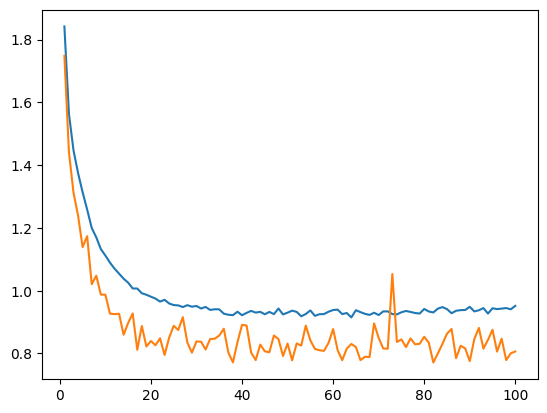

In [20]:
plt.plot(epochs , loss)
plt.plot(epochs , val_loss)